## Component A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [2]:
#loading the dataset
file_path = r"C:\Users\Tanya\Downloads\South Africa Road Accidents Dataset - 2017.xlsx"

df = pd.read_excel(file_path)

In [3]:
df.head()

,AccidentNo,Location,Police Force,Accident Severity,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Date,Time,Occations,Province,City,Street Name
0,1,Residential Area,2,Bumper Accident,6,Motocar,90km/h,60KM,1,2016,2018-01-01,22:00:00,Normal day,Gauteng,Pretoria,Mandela Street
1,2,Residential Area,2,Bumper Accident,6,Minibus,90km/h,60KM,1,2016,2018-01-02,23:00:00,Normal day,Gauteng,Pretoria,Mandela Street
2,3,Residential Area,2,Bumper Accident,6,Minibus Taxi,90km/h,60KM,1,2016,2018-01-03,1900-01-01 00:00:00,Normal day,Gauteng,Pretoria,Mandela Street
3,4,Residential Area,2,Bumper Accident,6,Bus,90km/h,60KM,1,2016,2018-01-04,1900-01-01 01:00:00,Normal day,Gauteng,Pretoria,Mandela Street
4,5,Residential Area,2,Bumper Accident,6,Motorcycle,90km/h,60KM,1,2016,2018-01-05,1900-01-01 02:00:00,Normal day,Gauteng,Pretoria,Mandela Street


In [39]:
print(df.columns)


Index(['AccidentNo', 'Location', 'Police Force', 'Accident Severity',
       'Number of Vehicles', 'Vehicle Type', 'Speed (km/h)', 'Speed Zone',
       'Number of Casualties', 'Year', 'Date', 'Time', 'Occations', 'Province',
       'City', 'Street Name'],
      dtype='object')


In [40]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_")
)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   AccidentNo            120 non-null    int64         
 1   Location              120 non-null    object        
 2   Police_Force          120 non-null    int64         
 3   Accident_Severity     120 non-null    object        
 4   Number_of_Vehicles    120 non-null    int64         
 5   Vehicle_Type          120 non-null    object        
 6   Speed_km_h            120 non-null    object        
 7   Speed_Zone            120 non-null    object        
 8   Number_of_Casualties  120 non-null    int64         
 9   Year                  120 non-null    int64         
 10  Date                  120 non-null    datetime64[ns]
 11  Time                  120 non-null    object        
 12  Occations             120 non-null    object        
 13  Province            

In [42]:
#shows the missing values in every coloumn
df.isnull().sum()

AccidentNo              0
Location                0
Police_Force            0
Accident_Severity       0
Number_of_Vehicles      0
Vehicle_Type            0
Speed_km_h              0
Speed_Zone              0
Number_of_Casualties    0
Year                    0
Date                    0
Time                    0
Occations               0
Province                0
City                    0
Street_Name             0
dtype: int64

In [43]:
# Convert Speed column to numeric (fixes string issues)
df["Speed_km_h"] = pd.to_numeric(df["Speed_km_h"], errors="coerce")

# Fill missing values using median (robust to outliers)
df["Speed_km_h"].fillna(df["Speed_km_h"].median(), inplace=True)

Using imputation could create some fake bias since there are no recorded values for Speed_km_h.
S, the feature gets either dropped or swapped out only if there's some solid estimation based on domain knowledge.

In [44]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful time-based features
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [45]:
# Convert Time to hour format
df["Time"] = pd.to_datetime(df["Time"], errors="coerce").dt.hour

# Fill missing Time values
df["Time"].fillna(df["Time"].median(), inplace=True)

In [46]:
# Drop original Date column (no longer needed)
df = df.drop(columns=["Date"])

In [47]:
df.describe()

,AccidentNo,Police_Force,Number_of_Vehicles,Speed_km_h,Number_of_Casualties,Year,Time,Month,DayOfWeek
count,120.000000,120.0,120.000000,0.0,120.000000,120.0,120.000000,120.000000,120.000000
mean,60.500000,2.0,2.991667,NaN,2.541667,2016.0,11.308333,2.500000,2.975000
std,34.785054,0.0,1.458074,NaN,0.839126,0.0,6.800637,1.130182,2.018663
min,1.000000,2.0,2.000000,NaN,1.000000,2016.0,0.000000,1.000000,0.000000
25%,30.750000,2.0,2.000000,NaN,2.000000,2016.0,5.750000,1.000000,1.000000
50%,60.500000,2.0,2.000000,NaN,3.000000,2016.0,11.000000,3.000000,3.000000
75%,90.250000,2.0,3.000000,NaN,3.000000,2016.0,17.000000,3.250000,5.000000
max,120.000000,2.0,6.000000,NaN,4.000000,2016.0,23.000000,4.000000,6.000000


In [60]:
# Automatically select categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

### Classification Coding

One-hot encoding was applied to transform categorical data into numerical formats with the help of `pd.get_dummies()`. To reduce multicollineari(two or more input features contain almost the same information)ty and avoid the dummy variable trap, the `drop_first=True` option was utilized.

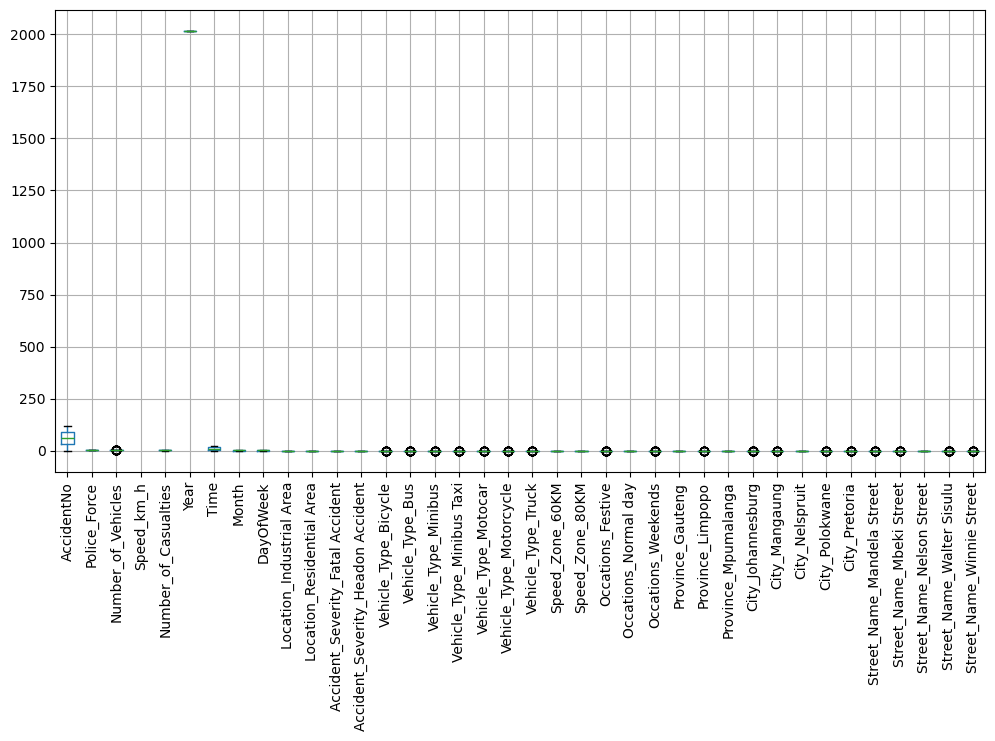

In [49]:
#detecting outliers
df.boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()

In [50]:
df["Speed_km_h"].fillna(df["Speed_km_h"].median(), inplace=True)

In [51]:
Q1 = df["Speed_km_h"].quantile(0.25)
Q3 = df["Speed_km_h"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Speed_km_h"] < lower) |
    (df["Speed_km_h"] > upper)
]

print(outliers.shape)

(0, 38)


### Spotting and Dealing with Outliers

We used boxplots along with the Interquartile Range (IQR) method to look for outliers. To make sure we didn't accidentally discard valid accident cases, we took a close look at extreme values in things like vehicle speed and casualty numbers before deciding to remove them.

# Step 2
The goal of this phase is to create ensemble learning models that predict the severity of accidents using the refined South African traffic accident dataset. We train and compare two ensemble models: Random Forest and XGBoost.


In [52]:
df['Target'] = df['Accident_Severity_Fatal Accident']


Severity-based one-hot columns were excluded from features to prevent target leakage.

In [53]:
# Check missing values in each column
print(df.isnull().sum())

AccidentNo                             0
Police_Force                           0
Number_of_Vehicles                     0
Speed_km_h                           120
Number_of_Casualties                   0
Year                                   0
Time                                   0
Month                                  0
DayOfWeek                              0
Location_Industrial Area               0
Location_Residential Area              0
Accident_Severity_Fatal Accident       0
Accident_Severity_Headon Accident      0
Vehicle_Type_Bicycle                   0
Vehicle_Type_Bus                       0
Vehicle_Type_Minibus                   0
Vehicle_Type_Minibus Taxi              0
Vehicle_Type_Motocar                   0
Vehicle_Type_Motorcycle                0
Vehicle_Type_Truck                     0
Speed_Zone_60KM                        0
Speed_Zone_80KM                        0
Occations_Festive                      0
Occations_Normal day                   0
Occations_Weeken

In [54]:
# Remove the completely empty column
df.drop(columns=['Speed_km_h'], inplace=True)

In [55]:
df.drop(columns=['AccidentNo'], inplace=True)

In [56]:
print(df['Target'].isnull().sum())

0


In [57]:
# Check for remaining missing values
print(df.isnull().sum().sum())

0


Before training models, the dataset was prepared by

1)Removing the missing column Speed_km_h
2)Dropping identifier column AccidentNo
3)Removing leakage features from Accident_Severity
4)Defining input features (X) and target variable (y)
5)Encoding categorical target labels into numeric form

In [66]:
# FEATURES AND TARGET
X = df.drop(columns=['Target'])
y = df['Target']

In [69]:
# ENCODE TARGET LABELS

# Create encoder
le = LabelEncoder()

# Convert text labels into numbers
y = le.fit_transform(y)

# Check encoded labels
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]


Severity-based one-hot columns were excluded from features to prevent target leakage.


===== Random Forest =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

===== XGBoost =====
Accuracy: 0.9583333333333334
Precision: 0.9605263157894736
Recall: 0.9583333333333334
F1 Score: 0.957002457002457


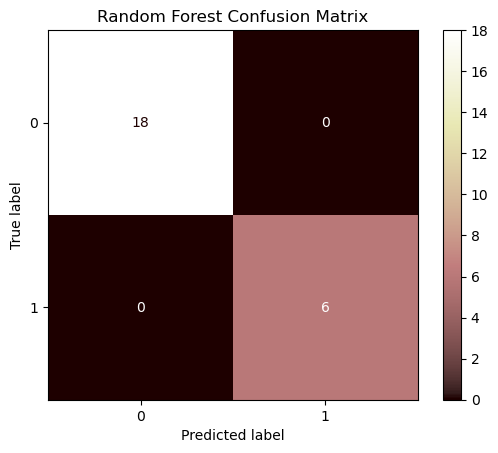

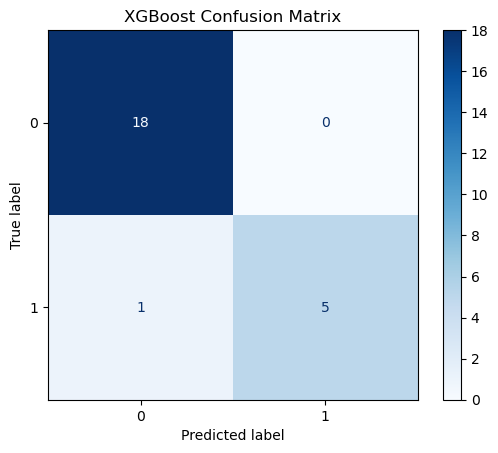

In [70]:
 #SPLIT DATA INTO TRAINING AND TESTING

# 80% training data
# 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# RANDOM FOREST MODEL


# Create Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)



# XGBOOST MODEl

# Create XGBoost classifier
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss'
)

# Train model
xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb.predict(X_test)



# EVALUATION FUNCTION

# Function to evaluate model performance
def evaluate_model(y_true, y_pred, model_name):

    print(f"\n===== {model_name} =====")

    # Accuracy
    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    # Precision
    print("Precision:",
          precision_score(
              y_true,
              y_pred,
              average='weighted'
          ))

    # Recall
    print("Recall:",
          recall_score(
              y_true,
              y_pred,
              average='weighted'
          ))

    # F1 Score
    print("F1 Score:",
          f1_score(
              y_true,
              y_pred,
              average='weighted'
          ))



# EVALUATE RANDOM FOREST


evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)



# EVALUATE XGBOOST


evaluate_model(
    y_test,
    y_pred_xgb,
    "XGBoost"
)



# CONFUSION MATRIX - RANDOM FOREST


# Generate confusion matrix for Random Forest predictions
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create display object for confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

# Plot confusion matrix using a soft pink colour map
disp_rf.plot(cmap="pink")

# Add title to the plot
plt.title("Random Forest Confusion Matrix")

# Display the plot
plt.show()




# CONFUSION MATRIX - XGBOOST

# Generate confusion matrix for XGBoost predictions
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Create display object for confusion matrix
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)

# Plot confusion matrix using a soft blue colour map
disp_xgb.plot(cmap="Blues")

# Add title to the plot
plt.title("XGBoost Confusion Matrix")

# Display the plot
plt.show()

# Step 3 Reinforcement Learning for Accident Prevention

## Defining the following
1. Markov Decision Process (MDP) Formulation

Accident prevention can be modelled as a Markov Decision Process (MDP) because decisions (interventions) influence future road safety states, and outcomes depend on both current conditions and chosen actions.
An MDP is defined by:

(S,A,P,R,γ)
S-Set of states
A-Set of actions
P-Transition probabilities
R-Reward Function
γ-Discount factor

2. States (S)

States represent the current traffic and road safety environment. Each state captures risk conditions that influence accident probability.
Examples of state variables:

-Road conditions: Good, Moderate, Poor
-Weather: Clear, Rainy, Foggy
-Traffic density: Low, Medium, High
-Accident frequency level: Low-risk, Medium-risk, High-risk zone
-Time-based risk: Peak hours vs off-peak

3. Actions (A)

Actions represent government or traffic authority interventions aimed at reducing accident risk.

Possible actions include:

Increased traffic police enforcement
Road safety awareness campaigns
Speed limit reduction enforcement
Deployment of traffic cameras
Road maintenance or hazard repairs
No intervention (baseline control action)
Example Action Set
A={A1,A2,A3,A4,A5}

Where:
A₁ = Increase enforcement intensity
A₂ = Launch awareness campaign
A₃ = Improve road infrastructure response
A₄ = Install monitoring systems
A₅ = No action

4. Reward Function (R)

The reward function measures the effectiveness of safety interventions.

The goal is to maximise safety and minimise accidents.

Reward Design Principles
Positive reward → reduction in accidents
Negative reward → increase in accident severity or no improvement
Example Reward Function
R=−(accident severity score)

*** Large reduction in accidents → +10 reward
No change → 0 reward
Increase in accidents → -10 reward

In [96]:
# ================================
# Q-LEARNING FOR ACCIDENT PREVENTION
# ================================

import numpy as np
import random

# Define MDP components
states = ["Low", "Medium", "High"]

actions = [
    "No_Action",
    "Increase_Police_Presence",
    "Speed_Cameras",
    "Awareness_Campaign"
]

# Initialize Q-table (state × action)
Q = np.zeros((len(states), len(actions)))

# Learning parameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate

# Reward function
def get_reward(state):
    if state == "Low":
        return 10
    elif state == "Medium":
        return 0
    else:
        return -10

# State transition function (simplified environment)
def next_state(state, action):
    if state == "High" and action != "No_Action":
        return "Medium"
    elif state == "Medium" and action != "No_Action":
        return "Low"
    else:
        return state

# Training loop
episodes = 500
convergence_tracker = []

for episode in range(episodes):

    state = random.choice(states)

    for step in range(10):

        s_idx = states.index(state)

        # exploration vs exploitation
        if random.uniform(0, 1) < epsilon:
            action = random.choice(actions)
        else:
            action = actions[np.argmax(Q[s_idx])]

        a_idx = actions.index(action)

        new_state = next_state(state, action)
        reward = get_reward(new_state)

        ns_idx = states.index(new_state)

        # Q-learning update rule
        Q[s_idx, a_idx] = Q[s_idx, a_idx] + alpha * (
            reward + gamma * np.max(Q[ns_idx]) - Q[s_idx, a_idx]
        )

        state = new_state

    # track convergence (max Q-value growth)
    convergence_tracker.append(np.max(Q))

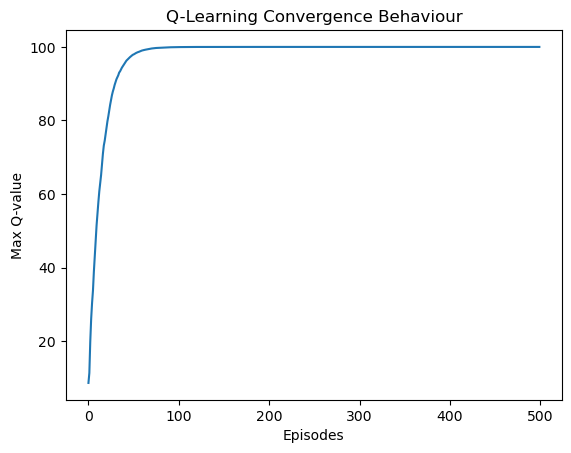

In [97]:
import matplotlib.pyplot as plt

plt.plot(convergence_tracker)
plt.title("Q-Learning Convergence Behaviour")
plt.xlabel("Episodes")
plt.ylabel("Max Q-value")
plt.show()

Throughout the episodes, the Q-values gradually become stable, indicating that the learning process is reaching its conclusion. This shows that the agent has successfully learned stable intervention policies.

In [98]:
# Extract optimal policy
policy = {}

for i, state in enumerate(states):
    best_action = actions[np.argmax(Q[i])]
    policy[state] = best_action

print("Optimal Policy Learned:")
for state, action in policy.items():
    print(state, "→", action)

Optimal Policy Learned:
Low → No_Action
Medium → Speed_Cameras
High → Increase_Police_Presence


The policy we've learned outlines the best intervention strategy for different risk levels.
For high-risk situations, we see strong measures like police enforcement or speed cameras, whereas low-risk situations need little to no intervention.

# Step 4

Remember that Ensemble Model (Prediction layer)

-predicts accident severity risk

RL Agent (Decision layer)

chooses intervention based on risk

In [99]:
# ENSEMBLE PREDICTIONS
predictions = xgb.predict(X_test)

# Convert predictions into RL states
states = ["Low", "Medium", "High"]

def get_state(pred):
    if pred == 0:
        return "Low"
    elif pred == 1:
        return "Medium"
    else:
        return "High"

rl_states = [get_state(p) for p in predictions]

In [100]:
# RL POLICY APPLICATION


actions = ["No_Action", "Police_Increase", "Speed_Cameras", "Awareness_Campaign"]

rl_actions = []

for state in rl_states:
    s_idx = states.index(state)
    action = actions[np.argmax(Q[s_idx])]
    rl_actions.append(action)

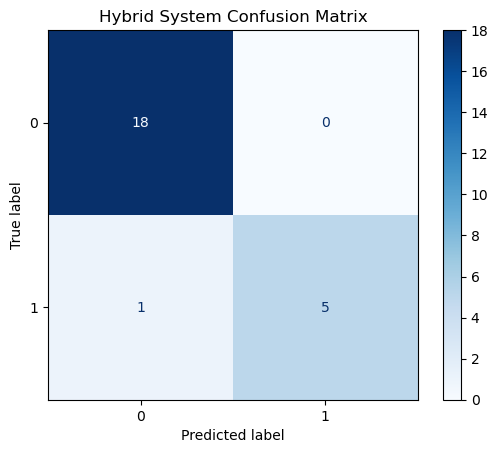

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Hybrid System Confusion Matrix")
plt.show()

In [102]:
import pandas as pd

policy_df = pd.DataFrame({
    "Predicted State": rl_states,
    "RL Action": rl_actions,
    "Actual Class": y_test[:len(rl_states)]
})

policy_df.head(10)

,Predicted State,RL Action,Actual Class
0,Low,No_Action,0
1,Low,No_Action,0
2,Medium,Speed_Cameras,1
3,Low,No_Action,0
4,Low,No_Action,0
5,Medium,Speed_Cameras,1
6,Low,No_Action,0
7,Medium,Speed_Cameras,1
8,Low,No_Action,0
9,Low,No_Action,0


Automated decision-making in road safety must be transparent; communities
   affected by interventions should understand why decisions are made.
   
2. Biased training data (e.g. underreporting in rural provinces) can lead to
   unequal resource allocation deploying more enforcement in already-marginalised areas.
   
4. The RL agent optimises a simplified reward; real-world deployment requires
   multi-stakeholder reward design including equity considerations.
   
6. Human-in-the-loop oversight is essential before any automated intervention
   is executed in safety-critical domains.